## **✅ Task 14: Model Comparison & Best Model Selection**

## **Importing the required Modules:**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## **Choose a dataset and apply necessary preprocessing steps once:**

In [2]:
df = pd.read_csv('Datasets/Titanic-Dataset.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [5]:
df['Embarked'].isnull().sum()

np.int64(2)

In [6]:
#review important features like Age, Sex, Fare, and Survived
df['Age'].isnull().sum()  # 177 null values

np.int64(177)

In [7]:
df['Survived'].value_counts() # These values are unevenly distributed

,count
Survived,
0,549
1,342


In [8]:
median_age = df['Age'].describe().loc['50%']
median_age

np.float64(28.0)

In [9]:
filtered_dataset = df.copy()

In [10]:
filtered_dataset['Age'].isnull().sum()

np.int64(177)

In [11]:
filtered_dataset['Age'] = filtered_dataset['Age'].fillna(median_age)

In [12]:
filtered_dataset['Age'].isnull().sum()

np.int64(0)

In [13]:
mode_embarked = filtered_dataset['Embarked'].mode()[0]
mode_embarked

'S'

In [14]:
filtered_dataset['Embarked'].isnull().sum()

np.int64(2)

In [15]:
filtered_dataset['Embarked'] = filtered_dataset['Embarked'].fillna(mode_embarked)

In [16]:
filtered_dataset['Embarked'].isnull().sum()

np.int64(0)

In [17]:
filtered_dataset = filtered_dataset.drop(columns=['PassengerId','Name'])

In [18]:
filtered_dataset.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,female,35.0,1,0,113803,53.1000,C123,S
4,0,3,male,35.0,0,0,373450,8.0500,NaN,S


In [19]:
filtered_dataset['Embarked'].unique()

array(['S', 'C', 'Q'], dtype=object)

### **Feature Encoding:**

In [20]:
from sklearn.preprocessing import OneHotEncoder

In [21]:
ohe = OneHotEncoder(handle_unknown='ignore',sparse_output=False).set_output(transform="pandas")

In [22]:
encoded = ohe.fit_transform(filtered_dataset[['Embarked','Sex']])

In [23]:
encoded.head()

,Embarked_C,Embarked_Q,Embarked_S,Sex_female,Sex_male
0,0.0,0.0,1.0,0.0,1.0
1,1.0,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,1.0,0.0
3,0.0,0.0,1.0,1.0,0.0
4,0.0,0.0,1.0,0.0,1.0


In [24]:
filtered_dataset.drop(columns= ['Embarked','Sex'],inplace=True)
filtered_dataset.head()

,Survived,Pclass,Age,SibSp,Parch,Ticket,Fare,Cabin
0,0,3,22.0,1,0,A/5 21171,7.2500,NaN
1,1,1,38.0,1,0,PC 17599,71.2833,C85
2,1,3,26.0,0,0,STON/O2. 3101282,7.9250,NaN
3,1,1,35.0,1,0,113803,53.1000,C123
4,0,3,35.0,0,0,373450,8.0500,NaN


In [25]:
filtered_dataset = pd.concat([filtered_dataset,encoded],axis=1)
filtered_dataset.head()

,Survived,Pclass,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S,Sex_female,Sex_male
0,0,3,22.0,1,0,A/5 21171,7.2500,NaN,0.0,0.0,1.0,0.0,1.0
1,1,1,38.0,1,0,PC 17599,71.2833,C85,1.0,0.0,0.0,1.0,0.0
2,1,3,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0.0,0.0,1.0,1.0,0.0
3,1,1,35.0,1,0,113803,53.1000,C123,0.0,0.0,1.0,1.0,0.0
4,0,3,35.0,0,0,373450,8.0500,NaN,0.0,0.0,1.0,0.0,1.0


### **Feature Scaling:**

In [26]:
from sklearn.preprocessing import StandardScaler

In [27]:
ss = StandardScaler().set_output(transform='pandas')

In [28]:
after_scaling = ss.fit_transform(filtered_dataset[['Age','Fare']])

In [29]:
after_scaling.head()

,Age,Fare
0,-0.565736,-0.502445
1,0.663861,0.786845
2,-0.258337,-0.488854
3,0.433312,0.420730
4,0.433312,-0.486337


In [30]:
filtered_dataset.drop(columns=['Age','Fare'],inplace=True)
filtered_dataset = pd.concat([filtered_dataset,after_scaling],axis=1)

In [31]:
filtered_dataset.head()

,Survived,Pclass,SibSp,Parch,Ticket,Cabin,Embarked_C,Embarked_Q,Embarked_S,Sex_female,Sex_male,Age,Fare
0,0,3,1,0,A/5 21171,NaN,0.0,0.0,1.0,0.0,1.0,-0.565736,-0.502445
1,1,1,1,0,PC 17599,C85,1.0,0.0,0.0,1.0,0.0,0.663861,0.786845
2,1,3,0,0,STON/O2. 3101282,NaN,0.0,0.0,1.0,1.0,0.0,-0.258337,-0.488854
3,1,1,1,0,113803,C123,0.0,0.0,1.0,1.0,0.0,0.433312,0.420730
4,0,3,0,0,373450,NaN,0.0,0.0,1.0,0.0,1.0,0.433312,-0.486337


In [32]:
filtered_dataset.drop(columns=['Cabin','Ticket'],inplace=True)

## **Split into train-test sets and keep the same split for all models:**

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [54]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

In [34]:
X = filtered_dataset.drop(columns = ['Survived'])
y = filtered_dataset['Survived']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=24)

## **Train multiple models such as Logistic Regression, Decision Tree, Random Forest,SVM:**

In [52]:
models = [LogisticRegression(),DecisionTreeClassifier(),RandomForestClassifier(),SVC()]

In [53]:
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

In [63]:
model_names = ['LogisticRegression','DecisionTree','RandomForestClassifier','SVC']

In [55]:
for model in models:
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    accuracy_scores.append(accuracy_score(y_test,y_pred) * 100)
    precision_scores.append(precision_score(y_test,y_pred) * 100)
    recall_scores.append(recall_score(y_test,y_pred) * 100)
    f1_scores.append(f1_score(y_test,y_pred) * 100)

## **Predict test results for all models:**

In [57]:
accuracy_scores

[82.46268656716418, 75.3731343283582, 82.83582089552239, 82.83582089552239]

In [58]:
precision_scores

[76.08695652173914, 64.35643564356435, 76.92307692307693, 78.16091954022988]

In [59]:
recall_scores

[73.68421052631578, 68.42105263157895, 73.68421052631578, 71.57894736842105]

In [60]:
f1_scores

[74.8663101604278, 66.3265306122449, 75.26881720430107, 74.72527472527473]

## **Evaluate each model using accuracy, precision, recall, F1-score:**

In [64]:
comparision = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1 Score': f1_scores
})

In [65]:
comparision

,Model,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,82.462687,76.086957,73.684211,74.866310
1,DecisionTree,75.373134,64.356436,68.421053,66.326531
2,RandomForestClassifier,82.835821,76.923077,73.684211,75.268817
3,SVC,82.835821,78.160920,71.578947,74.725275


## **Plot bar chart comparing performance across models:**

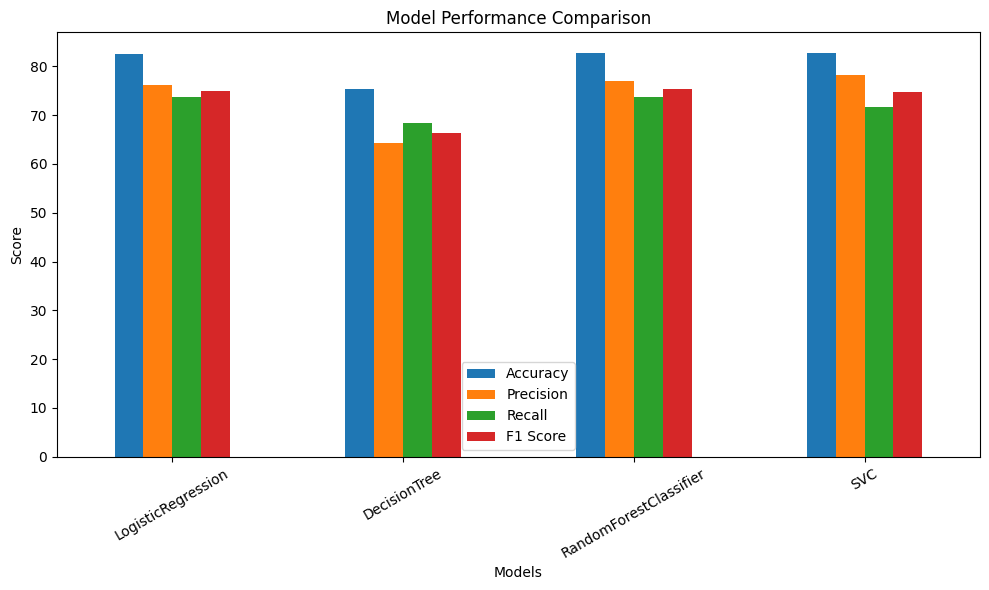

In [70]:
comparision.plot(kind='bar', figsize=(10,6))

plt.title("Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('comparision_model_performance.png')
plt.show()

In [81]:
train_acc = []
test_acc = []

## **Identify which model generalizes best by comparing train vs test scores:**

In [82]:
for model in models:
  y_pred_train = model.predict(X_train)
  y_pred_test = model.predict(X_test)
  train_acc.append(accuracy_score(y_train,y_pred_train) * 100)
  test_acc.append((accuracy_score(y_test,y_pred_test)) * 100)


In [83]:
train_acc

[78.97271268057786, 98.3948635634029, 98.3948635634029, 82.8250401284109]

In [84]:
test_acc

[82.46268656716418, 75.3731343283582, 82.83582089552239, 82.83582089552239]

In [89]:
comparision_train_test = pd.DataFrame({
    "Model": model_names,
    "Train Accuracy": train_acc,
    "Test Accuracy": test_acc
})
comparision_train_test.set_index("Model", inplace=True)

In [90]:
comparision_train_test["Gap"] = (
    comparision_train_test["Train Accuracy"] -
    comparision_train_test["Test Accuracy"]
)

In [91]:
comparision_train_test

,Train Accuracy,Test Accuracy,Gap
Model,,,
LogisticRegression,78.972713,82.462687,-3.489974
DecisionTree,98.394864,75.373134,23.021729
RandomForestClassifier,98.394864,82.835821,15.559043
SVC,82.825040,82.835821,-0.010781


In [92]:
comparision_train_test.sort_values(by="Gap", inplace=True)
comparision_train_test

,Train Accuracy,Test Accuracy,Gap
Model,,,
LogisticRegression,78.972713,82.462687,-3.489974
SVC,82.825040,82.835821,-0.010781
RandomForestClassifier,98.394864,82.835821,15.559043
DecisionTree,98.394864,75.373134,23.021729


## **Select best model based on business requirement and save it:**

In [93]:
best_model = comparision_train_test["Test Accuracy"].idxmax()

print("Best Model:", best_model)

Best Model: SVC


In [94]:
import joblib

In [97]:
models

[LogisticRegression(),
 DecisionTreeClassifier(),
 RandomForestClassifier(),
 SVC()]

In [98]:
joblib.dump(models[3], "best_model.pkl")

['best_model.pkl']